# Estatística 1 - Aula prática 3_2 em Python

## UNIDADE 3: Distribuições de probabilidade

### Seção 3.2: Distribuições contínuas

By Jose P. Leitão

#### Distribuição Normal Padronizada (Z)

In [49]:
%matplotlib inline
# Importar bibliotecas
import numpy as np

from scipy.stats import norm, t, chi2, f, logistic

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

# Define o formato de saída para SVG
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import warnings
warnings.filterwarnings('ignore')

In [50]:
# Para obter os valores da tabela Z, com 2,5% na cauda da 
# esquerda e direita:
print(norm.ppf(0.025))
print(norm.ppf(0.975))

-1.9599639845400545
1.959963984540054


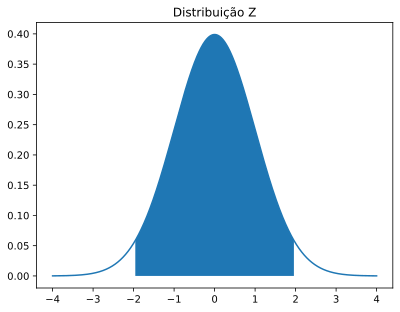

In [51]:
# Para obter um grafico da distribuicao Z para a area de 95%:
# pnormGC(c(-1.96,1.96),region="between",mean=0,
#         sd=1,graph=TRUE)
q1 = norm.ppf(0.025) # -1.96
q2 = norm.ppf(0.975) # 1.96
mu = 0
sigma = 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.plot(x, y)
plt.fill_between(x, y, where=((x >= q1) & (x <= q2) ))
plt.title("Distribuição Z")
plt.show()

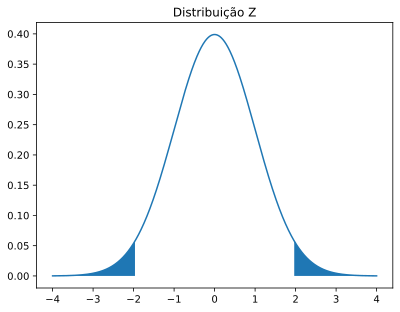

In [52]:
# Para as areas de 2,5% (que somadas representam 5%):
# pnormGC(c(-1.96,1.96),region="outside",mean=0,
#         sd=1,graph=TRUE)

q1 = norm.ppf(0.025) # -1.96
q2 = norm.ppf(0.975) # 1.96
mu = 0
sigma = 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.plot(x, y)
plt.fill_between(x, y, where=((x < q1) | (x > q2)))
plt.title("Distribuição Z")
plt.show()

In [53]:
# Nos testes de hipoteses essas areas das caudas sao utilizadas
# para testar a hipotese H0, representam a area de rejeicao de H0

#### Distribuição "t" de Student

In [54]:
# Por exemplo, para 95% de confianca e 25 graus de liberdade
# t = 2.06, para a tabela t tambem deve-se colocar 2,5% porque
# os valores sao para uma cauda

# Para obter os valores da tabela t, para 2,5% na da cauda 
# esquerda e direita, para 25 graus de liberdade:

print(t.ppf(0.025, 25))
print(t.ppf(0.975, 25))

-2.059538552753297
2.0595385527532972


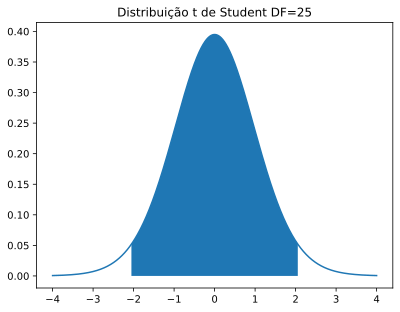

In [55]:
# Construindo um grafico para destacar os 95% da distribuicao

df = 25
q1 = t.ppf(0.025, df) # -2.05
q2 = t.ppf(0.975, df) # 2.05

x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)

plt.plot(x, y)
plt.fill_between(x, y, where=((x >= q1) & (x <= q2) ))
plt.title("Distribuição t de Student DF=25")
plt.show()

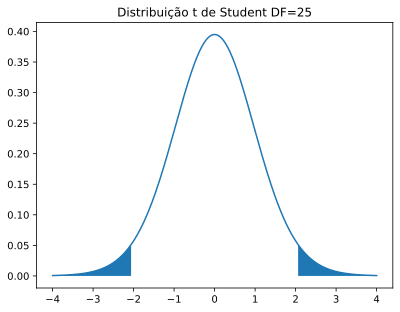

In [56]:
# Feito de outra forma, para destacar os 5% da distribuicao

df = 25
q1 = t.ppf(0.025, df) # -2.05
q2 = t.ppf(0.975, df) # 2.05


x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)

plt.plot(x, y)
plt.fill_between(x, y, where=((x < q1) | (x > q2)))
plt.title("Distribuição t de Student DF=25")
plt.show()

#### Distribuição Chi-Square $\chi^2$

In [57]:
# Por exemplo, com 5 graus de liberdade e 5% de probabilidade
# (1.145476) na cauda inferior e 95% (11.0705) na cauda superior

# Obtendo os valores criticos (da tabela)
print(chi2.ppf(0.05, 5))
print(chi2.ppf(0.95, 5))

1.1454762260617692
11.070497693516351


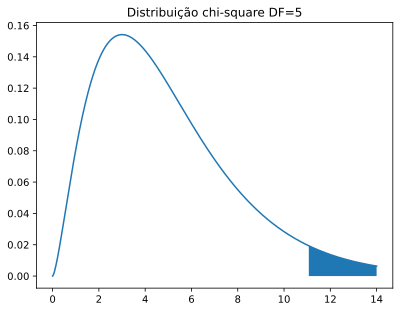

In [58]:
# Construindo o grafico para destacar os 5% do lado superior
# da distribuicao

df = 5
q1 = chi2.ppf(0.05, df) # 1.145476
q2 = chi2.ppf(0.95, df) # 11.0705

x = np.linspace(0, 14, 1000)
y = chi2.pdf(x, df)

plt.plot(x, y)
plt.fill_between(x, y, where=((x > q2) ))
plt.title("Distribuição chi-square DF=5")
plt.show()


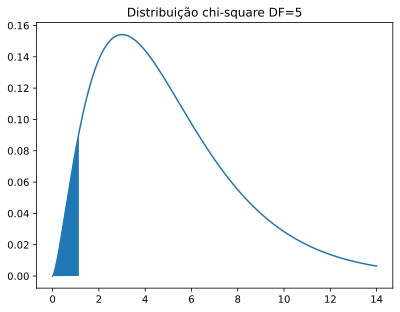

In [59]:
# Outra forma de grafico para destacar os 5% do lado inferior
# da distribuicao
#pchisqGC(c(1.145476),region="below",df=5, graph = TRUE)
df = 5
q1 = chi2.ppf(0.05, df) # 1.145476
q2 = chi2.ppf(0.95, df) # 11.0705

x = np.linspace(0, 14, 1000)
y = chi2.pdf(x, df)

plt.plot(x, y)
plt.fill_between(x, y, where=((x < q1) ))
plt.title("Distribuição chi-square DF=5")
plt.show()


#### Distribuição "F" de Fisher e Snedecor

In [60]:
# Por exemplo, com 20 graus de liberdade no numerador e 19 graus
# de liberdade no denominador temos:
f.ppf(0.95, 20, 19)

np.float64(2.155496637131509)

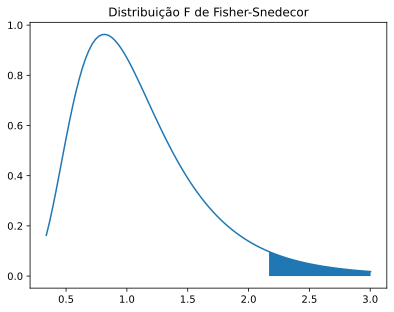

In [61]:
# Plotando o grafico
dg1 = 20
dg2 = 19
q2 = f.ppf(0.95, 20, 19)
x = np.linspace(f.ppf(0.01, dg1, dg2),
                f.ppf(0.99, dg1, dg2), 100)
y = f.pdf(x, dg1, dg2)

plt.plot(x, y)
plt.fill_between(x, y, where=((x > q2) ))
plt.title("Distribuição F de Fisher-Snedecor")
plt.show()

#### Distribuição logística

In [62]:
# Obtendo o valor tabelado para 5% de significancia
#qlogis(0.95)
logistic.ppf(0.95)

np.float64(2.9444389791664394)

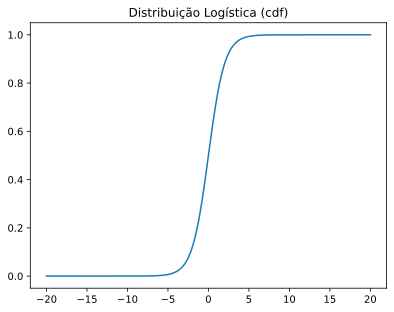

In [63]:
# Para plotar o grafico eh necessario:
# Criar um vetor x de valores, aqui exemplificamos uma sequencia 
# de numeros de -20 a 20, a cada 0,10 

x = np.linspace(-20, 20, 400)
# Se deseja ver os valores:
#print(x)

# Chamando a funcao plogis() sobre os valores: 
y = logistic.cdf(x) 

# A funcao de probabilidade logistica (plogis) transforma os
# valores em probabilidade no intervalo entre 0 a 1 

# Plotando o grafico: 
plt.plot(x, y)
plt.title("Distribuição Logística (cdf)")
plt.show()